<a href="https://colab.research.google.com/github/Afroj34669/Afroj-alam/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SNR: 0 BER: 0.1598515625
SNR: 2 BER: 0.1035234375
SNR: 4 BER: 0.0553515625
SNR: 6 BER: 0.0230078125
SNR: 8 BER: 0.00559375
SNR: 10 BER: 0.0007734375
SNR: 12 BER: 2.34375e-05
SNR: 14 BER: 0.0
SNR: 16 BER: 0.0
SNR: 18 BER: 0.0
SNR: 20 BER: 0.0


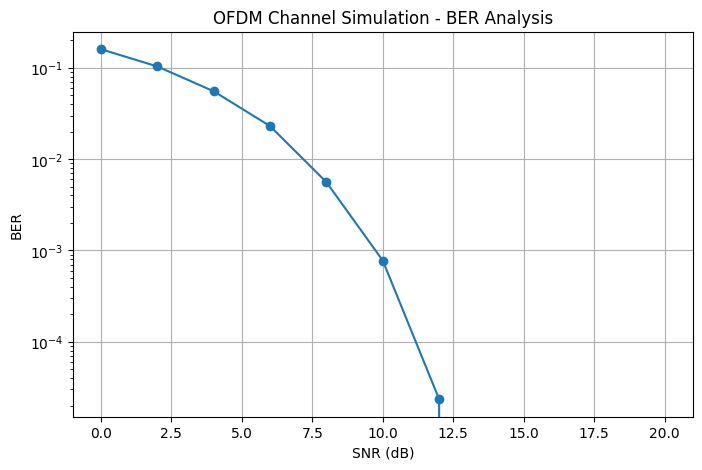

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Parameters ----------------
N = 64                 # Number of OFDM subcarriers
CP = 16                # Cyclic prefix length
num_symbols = 1000     # OFDM symbols

SNR_dB = np.arange(0, 21, 2)

# ---------------- QPSK Modulation ----------------
def qpsk_mod(bits):
    bits = bits.reshape((-1,2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    return symbols/np.sqrt(2)


# ---------------- QPSK Demodulation ----------------
def qpsk_demod(symbols):
    bits = np.zeros((len(symbols),2),dtype=int)

    bits[:,0] = (symbols.real > 0)
    bits[:,1] = (symbols.imag > 0)

    return bits.flatten()


# ---------------- OFDM Transmitter ----------------
def ofdm_tx(bits):

    symbols = qpsk_mod(bits)

    symbols = symbols[:N*num_symbols]

    ofdm_signal = []

    symbols = symbols.reshape(num_symbols,N)

    for i in range(num_symbols):

        time_signal = np.fft.ifft(symbols[i])

        cp = time_signal[-CP:]

        tx = np.concatenate([cp,time_signal])

        ofdm_signal.extend(tx)

    return np.array(ofdm_signal)



# ---------------- Channel ----------------
def awgn(signal,snr):

    power = np.mean(abs(signal)**2)

    snr_linear = 10**(snr/10)

    noise_power = power/snr_linear

    noise = np.sqrt(noise_power/2)*(
        np.random.randn(len(signal))
        +1j*np.random.randn(len(signal))
    )

    return signal+noise



# ---------------- Receiver ----------------
def ofdm_rx(signal):

    rx_symbols=[]

    length=N+CP

    for i in range(num_symbols):

        block = signal[i*length:(i+1)*length]

        block = block[CP:]

        freq = np.fft.fft(block)

        rx_symbols.extend(freq)

    return np.array(rx_symbols)



# ---------------- Simulation ----------------

BER=[]


bits = np.random.randint(
    0,2,
    2*N*num_symbols
)


tx_signal = ofdm_tx(bits)


for snr in SNR_dB:

    rx_signal = awgn(tx_signal,snr)

    received = ofdm_rx(rx_signal)


    demod_bits = qpsk_demod(received)


    errors = np.sum(bits != demod_bits)

    ber = errors/len(bits)

    BER.append(ber)


    print(
        "SNR:",
        snr,
        "BER:",
        ber
    )


# ---------------- Plot ----------------

plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    BER,
    'o-'
)

plt.grid(True)

plt.xlabel("SNR (dB)")
plt.ylabel("BER")

plt.title(
    "OFDM Channel Simulation - BER Analysis"
)

plt.show()

### 16-QAM Modulation and Demodulation

To compare performance, I'll implement 16-QAM modulation and demodulation functions. 16-QAM transmits 4 bits per symbol, offering a higher data rate than QPSK (2 bits per symbol) but typically requires a higher SNR for the same BER.

In [2]:
# ---------------- 16-QAM Modulation ----------------
def qam16_mod(bits):
    # Reshape bits into groups of 4 for 16-QAM
    bits = bits.reshape((-1, 4))

    # Map 4 bits to 16-QAM symbols
    # The constellation points for 16-QAM are typically (\pm1, \pm1), (\pm1, \pm3), (\pm3, \pm1), (\pm3, \pm3)
    # We'll normalize by sqrt(10) for average energy 1
    real_part = (2 * bits[:, 0] - 1) * 2 + (2 * bits[:, 1] - 1)  # MSB determines outer/inner, LSB determines sign
    imag_part = (2 * bits[:, 2] - 1) * 2 + (2 * bits[:, 3] - 1)

    symbols = real_part + 1j * imag_part
    return symbols / np.sqrt(10) # Normalization factor for average power of 1

# ---------------- 16-QAM Demodulation ----------------
def qam16_demod(symbols):
    # Demodulate 16-QAM symbols back to bits
    bits = np.zeros((len(symbols), 4), dtype=int)

    # Denormalize symbols for easier thresholding
    symbols = symbols * np.sqrt(10)

    # Demodulate real part
    real_part = symbols.real
    bits[:, 0] = (real_part > 0) # MSB for real part
    bits[:, 1] = ((real_part > 2) | ((real_part < 0) & (real_part > -2))) # LSB for real part

    # Demodulate imaginary part
    imag_part = symbols.imag
    bits[:, 2] = (imag_part > 0) # MSB for imag part
    bits[:, 3] = ((imag_part > 2) | ((imag_part < 0) & (imag_part > -2))) # LSB for imag part

    return bits.flatten()


### 16-QAM OFDM Simulation

Now, I will run the OFDM simulation again, but this time using 16-QAM modulation, and store its BER results. I'll then combine the QPSK and 16-QAM results into a single plot.

In [6]:
# ---------------- 16-QAM OFDM Transmitter ----------------
def ofdm_tx_qam16(bits):
    symbols = qam16_mod(bits)

    symbols = symbols[:N*num_symbols]

    ofdm_signal = []

    symbols = symbols.reshape(num_symbols,N)

    for i in range(num_symbols):

        time_signal = np.fft.ifft(symbols[i])

        cp = time_signal[-CP:]

        tx = np.concatenate([cp,time_signal])

        ofdm_signal.extend(tx)

    return np.array(ofdm_signal)

# ---------------- Simulation for 16-QAM ----------------

BER_qam16 = []

# For 16-QAM, we need 4 bits per symbol (2*N*num_symbols * 2 for QPSK, *4 for 16QAM)
# The number of bits for 16-QAM is 4 * N * num_symbols
bits_qam16 = np.random.randint(
    0, 2,
    4 * N * num_symbols
)

tx_signal_qam16 = ofdm_tx_qam16(bits_qam16)

print("\n--- 16-QAM Simulation Results ---")
for snr in SNR_dB:
    rx_signal_qam16 = awgn(tx_signal_qam16, snr)
    received_qam16 = ofdm_rx(rx_signal_qam16)
    demod_bits_qam16 = qam16_demod(received_qam16)

    errors_qam16 = np.sum(bits_qam16 != demod_bits_qam16)
    ber_qam16 = errors_qam16 / len(bits_qam16)
    BER_qam16.append(ber_qam16)

    print(
        "SNR:",
        snr,
        "BER (16-QAM):",
        ber_qam16
    )



--- 16-QAM Simulation Results ---
SNR: 0 BER (16-QAM): 0.30877734375
SNR: 2 BER (16-QAM): 0.27918359375
SNR: 4 BER (16-QAM): 0.23604296875
SNR: 6 BER (16-QAM): 0.186578125
SNR: 8 BER (16-QAM): 0.13053515625
SNR: 10 BER (16-QAM): 0.07867578125
SNR: 12 BER (16-QAM): 0.037078125
SNR: 14 BER (16-QAM): 0.01214453125
SNR: 16 BER (16-QAM): 0.002265625
SNR: 18 BER (16-QAM): 0.00025390625
SNR: 20 BER (16-QAM): 1.5625e-05


### Comparison Plot (QPSK vs 16-QAM)

This plot shows the BER performance of both QPSK and 16-QAM modulation schemes under the same AWGN channel conditions. As expected, 16-QAM requires a higher SNR to achieve the same BER as QPSK due to its higher spectral efficiency (transmitting more bits per symbol).

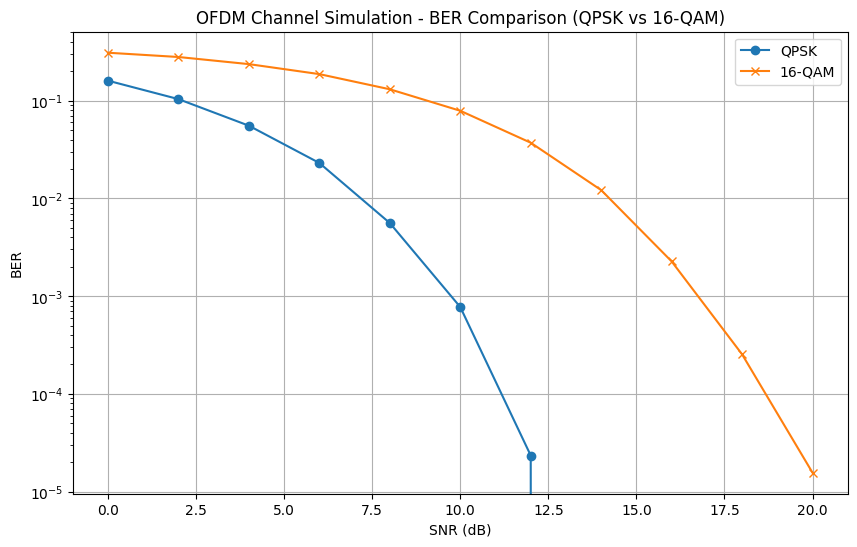

In [7]:
plt.figure(figsize=(10, 6))

plt.semilogy(
    SNR_dB,
    BER,
    'o-', # QPSK result
    label='QPSK'
)

plt.semilogy(
    SNR_dB,
    BER_qam16,
    'x-', # 16-QAM result
    label='16-QAM'
)

plt.grid(True)
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("OFDM Channel Simulation - BER Comparison (QPSK vs 16-QAM)")
plt.legend()
plt.show()
